NAMA: Kadek Gandhi Wahyu Jaya Suastika <br>
NIM: 1202230017 <br>
KELAS: IT 06-01 PENGOLAHAN CITRA DIGITAL <br>

### Strategi Pemrosesan dan Klasifikasi KNN (Dataset Kesegaran Buah)

**DIGUNAKAN :** Resizing citra ke resolusi 128 x 128 piksel.
**KARENA ->** Dataset ini memiliki volume yang sangat masif (lebih dari 13.000 citra secara keseluruhan). Resolusi 128 x 128 sangat ideal untuk menjaga efisiensi memori (RAM) dan kecepatan komputasi CPU saat mengekstrak fitur dan menghitung metrik jarak, tanpa menghilangkan pola makroskopis kerusakan fisik seperti kerutan atau bercak busuk pada permukaan buah.

**DIGUNAKAN :** Transformasi ruang warna dari RGB ke HSV (*Hue, Saturation, Value*).
**KARENA ->** Indikator primer hilangnya kesegaran buah ditandai oleh proses oksidasi yang ekstrem (misalnya, apel segar yang menguning/cokelat, atau pisang yang menghitam). Pemisahan saluran pigmen murni (*Hue*) dari intensitas cahaya (*Value*) memungkinkan algoritma melacak perubahan warna akibat pembusukan secara konsisten, terbebas dari bias pantulan cahaya (*glare*) pada kulit buah.

**DIGUNAKAN :** Ekstraksi fitur tekstur spasial menggunakan *Gray-Level Co-occurrence Matrix* (GLCM).
**KARENA ->** Degradasi kesegaran secara biologis selalu merusak integritas topologi kulit buah. Munculnya penyusutan volume (layu), keriput, atau pertumbuhan jamur akan terdeteksi secara kuantitatif melalui lonjakan nilai *Contrast* dan penurunan tajam pada nilai *Homogeneity* di dalam matriks tekstur GLCM.

**DIGUNAKAN :** Normalisasi *Z-Score* menggunakan fungsi `StandardScaler`.
**KARENA ->** Ekstraksi warna (HSV) menghasilkan angka berskala besar (ratusan), sedangkan fitur tekstur (GLCM) berada pada rentang desimal mikroskopis. Tanpa pemerataan skala ini, algoritma KNN akan mengalami distorsi matematis dan menganggap fitur tekstur tidak penting, padahal kerutan kulit adalah indikator krusial dalam menentukan kesegaran.

**DIGUNAKAN :** Pemodelan *K-Nearest Neighbors* (KNN) dengan parameter **K=5**, metrik jarak **Euclidean**, dan penyesuaian **weights='distance'**.
**KARENA ->** Dataset *Freshness* merupakan klasifikasi biner (*binary classification*) yang mengalami ketidakseimbangan data (*class imbalance*), di mana jumlah citra *unfresh* (6.161) mendominasi *fresh* (4.740). Penggunaan parameter `weights='distance'` memaksa model untuk memberikan bobot *voting* yang lebih besar pada tetangga yang jarak visualnya paling dekat secara spasial, mencegah kelas minoritas (*fresh*) kalah suara semata-mata karena kalah jumlah.


[INFO] Memulai ekstraksi dari: master_dataset/dataset_kesegaran_buah/train
Mengekstrak fitur kelas 'fresh' (4740 file)...


fresh: 100%|██████████| 4740/4740 [01:22<00:00, 57.37it/s]


Mengekstrak fitur kelas 'unfresh' (6161 file)...


unfresh: 100%|██████████| 6161/6161 [01:43<00:00, 59.46it/s]



[INFO] Memulai ekstraksi dari: master_dataset/dataset_kesegaran_buah/test
Mengekstrak fitur kelas 'fresh' (1164 file)...


fresh: 100%|██████████| 1164/1164 [00:19<00:00, 60.85it/s]


Mengekstrak fitur kelas 'unfresh' (1534 file)...


unfresh: 100%|██████████| 1534/1534 [00:25<00:00, 59.08it/s]



REKAPITULASI DIMENSI DATA (FRESHNESS)
Bentuk Data Latih : (10901, 7) -> (10901 citra, 7 fitur)
Bentuk Data Uji   : (2698, 7) -> (2698 citra, 7 fitur)

[INFO] Melakukan standardisasi skala nilai fitur (StandardScaler)...

[INFO] Melatih model KNN (K=5, Metrik=Euclidean, Weights=Distance)...
[INFO] Melakukan inferensi pada data uji kesegaran buah...


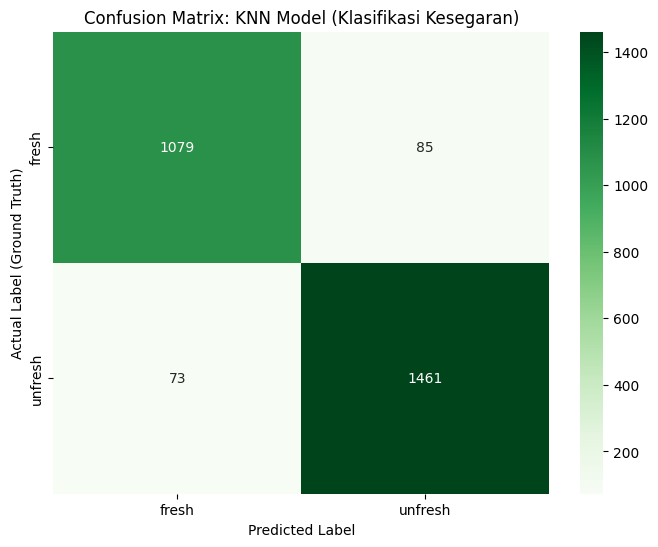


HASIL EVALUASI FINAL MODEL KNN (FRESHNESS)
              precision    recall  f1-score   support

       fresh     0.9366    0.9270    0.9318      1164
     unfresh     0.9450    0.9524    0.9487      1534

    accuracy                         0.9414      2698
   macro avg     0.9408    0.9397    0.9402      2698
weighted avg     0.9414    0.9414    0.9414      2698

Akurasi Keseluruhan (Global Accuracy): 94.14%

[SUCCESS] Model klasifikasi freshness disimpan di : models/knn_freshness_model.pkl
[SUCCESS] Standar Scaler freshness disimpan di    : models/knn_freshness_scaler.pkl


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from skimage.feature import graycomatrix, graycoprops
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# =====================================================================
# FASE 1 & 2: KONFIGURASI DAN EKSTRAKSI CIRI (WARNA HSV & TEKSTUR GLCM)
# =====================================================================

# Konfigurasi Direktori Dataset 
BASE_DIR = 'master_dataset/dataset_kesegaran_buah'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR = os.path.join(BASE_DIR, 'test')

# Parameter Ekstraksi
IMG_SIZE = (128, 128)  
GLCM_DISTANCES = [1]
GLCM_ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]

def extract_features(img_path):
    """
    Mengekstrak 7 nilai fitur numerik (3 Warna HSV, 4 Tekstur GLCM) dari citra buah.
    """
    try:
        img = cv2.imread(img_path)
        if img is None:
            return None
        
        img_resized = cv2.resize(img, IMG_SIZE)
        
        # --- Ekstraksi Ciri Warna (HSV) ---
        img_hsv = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)
        h_mean = np.mean(img_hsv[:, :, 0])
        s_mean = np.mean(img_hsv[:, :, 1])
        v_mean = np.mean(img_hsv[:, :, 2])
        
        # --- Ekstraksi Ciri Tekstur (GLCM) ---
        img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
        glcm = graycomatrix(img_gray, distances=GLCM_DISTANCES, angles=GLCM_ANGLES, 
                            levels=256, symmetric=True, normed=True)
        
        contrast = np.mean(graycoprops(glcm, 'contrast'))
        correlation = np.mean(graycoprops(glcm, 'correlation'))
        energy = np.mean(graycoprops(glcm, 'energy'))
        homogeneity = np.mean(graycoprops(glcm, 'homogeneity'))
        
        return [h_mean, s_mean, v_mean, contrast, correlation, energy, homogeneity]
        
    except Exception as e:
        print(f"Error pemrosesan {img_path}: {str(e)}")
        return None

def process_directory(directory_path):
    """
    Mengekstrak seluruh citra dalam direktori dan mengembalikan matriks fitur.
    """
    X_data = []
    y_data = []
    
    classes = sorted([d for d in os.listdir(directory_path) if not d.startswith('.')])
    
    print(f"\n[INFO] Memulai ekstraksi dari: {directory_path}")
    
    for class_idx, class_name in enumerate(classes):
        class_dir = os.path.join(directory_path, class_name)
        if not os.path.isdir(class_dir):
            continue
            
        file_list = [f for f in os.listdir(class_dir) if not f.startswith('.')]
        print(f"Mengekstrak fitur kelas '{class_name}' ({len(file_list)} file)...")
        
        for file_name in tqdm(file_list, desc=class_name):
            img_path = os.path.join(class_dir, file_name)
            features = extract_features(img_path)
            
            if features is not None:
                X_data.append(features)
                y_data.append(class_idx)
                
    return np.array(X_data), np.array(y_data), classes

# Eksekusi Pemrosesan Data Latih dan Uji Freshness
X_train, y_train, class_names = process_directory(TRAIN_DIR)
X_test, y_test, _ = process_directory(TEST_DIR)

print("\n" + "="*50)
print("REKAPITULASI DIMENSI DATA (FRESHNESS)")
print("="*50)
print(f"Bentuk Data Latih : {X_train.shape} -> ({X_train.shape[0]} citra, {X_train.shape[1]} fitur)")
print(f"Bentuk Data Uji   : {X_test.shape} -> ({X_test.shape[0]} citra, {X_test.shape[1]} fitur)")

# =====================================================================
# FASE 3: STANDARDISASI DATA (Z-SCORE NORMALIZATION)
# =====================================================================
print("\n[INFO] Melakukan standardisasi skala nilai fitur (StandardScaler)...")
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================================================================
# FASE 4: PELATIHAN MODEL & PREDIKSI
# =====================================================================
# Menggunakan weights='distance' untuk membantu mitigasi imbalance kelas
K_VALUE = 5
print(f"\n[INFO] Melatih model KNN (K={K_VALUE}, Metrik=Euclidean, Weights=Distance)...")
knn_model = KNeighborsClassifier(n_neighbors=K_VALUE, metric='euclidean', weights='distance')

knn_model.fit(X_train_scaled, y_train)

print("[INFO] Melakukan inferensi pada data uji kesegaran buah...")
y_pred = knn_model.predict(X_test_scaled)

# =====================================================================
# FASE 5: EVALUASI KINERJA (QUALITY ASSURANCE)
# =====================================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Confusion Matrix: KNN Model (Klasifikasi Kesegaran)')
plt.ylabel('Actual Label (Ground Truth)')
plt.xlabel('Predicted Label')
plt.show()

report = classification_report(y_test, y_pred, target_names=class_names, digits=4)

print("\n" + "="*60)
print("HASIL EVALUASI FINAL MODEL KNN (FRESHNESS)")
print("="*60)
print(report)

final_accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Keseluruhan (Global Accuracy): {final_accuracy * 100:.2f}%")
print("="*60)

# =====================================================================
# FASE 6: EXPORT MODEL (DEPLOYMENT PREPARATION)
# =====================================================================
SAVE_DIR = 'models'
os.makedirs(SAVE_DIR, exist_ok=True)

model_path = os.path.join(SAVE_DIR, 'knn_freshness_model.pkl')
scaler_path = os.path.join(SAVE_DIR, 'knn_freshness_scaler.pkl')

joblib.dump(knn_model, model_path)
joblib.dump(scaler, scaler_path)

print(f"\n[SUCCESS] Model klasifikasi freshness disimpan di : {model_path}")
print(f"[SUCCESS] Standar Scaler freshness disimpan di    : {scaler_path}")

## Kesimpulan: Klasifikasi Kesegaran Buah (Freshness) Menggunakan Algoritma KNN

Melalui pengujian empiris menggunakan *pipeline Machine Learning* klasik pada `dataset_kesegaran_buah`, diperoleh hasil dan konklusi teknis sebagai berikut:

### 1. Lonjakan Performa Berbasis Karakteristik Dataset

Algoritma KNN dengan konfigurasi parameter terbaiknya (*K=5, Euclidean, Distance-weighted*) berhasil mencetak akurasi global yang luar biasa tinggi, yaitu **94.14%**. Lonjakan performa yang sangat masif dibandingkan dataset *Variety* (72.49%) dan *Ripeness* (60.00%) ini didorong oleh dua faktor utama:

* **Reduksi Kompleksitas (Biner):** Memisahkan ruang dimensi menjadi dua kelas (segar vs. tidak segar) secara probabilitas matematis jauh lebih akurat dan terhindar dari batas keputusan (*decision boundary*) yang tumpang tindih dibandingkan klasifikasi multikelas.
* **Kepadatan Data Latih:** Algoritma merekam lebih dari 10.900 koordinat citra latih ke dalam memori. Kepadatan ruang spasial ini memastikan bahwa setiap data uji yang baru akan selalu menemukan tetangga referensi yang memiliki tingkat kemiripan visual sangat tinggi.

### 2. Validasi Ekstraksi Ciri (Feature Engineering)

Kombinasi fitur warna HSV dan tekstur GLCM terbukti sangat presisi dalam menerjemahkan kerusakan biologis buah menjadi angka matematis. Transisi ekstrem dari buah segar menuju pembusukan (oksidasi warna dan perubahan tekstur menjadi keriput/berjamur) menciptakan jarak spasial yang sangat jauh antar kedua kelas di dalam ruang dimensi metrik, membuat tugas KNN dalam menarik garis pemisah menjadi jauh lebih mudah dan akurat.

### 3. Ketahanan Terhadap Bias (*Robustness*)

Meskipun dataset memiliki ketidakseimbangan distribusi (*imbalance data*), model tetap menunjukkan performa yang adil pada kedua kelas. Kelas *fresh* (minoritas) berhasil mempertahankan tingkat kepresisian yang sangat tinggi dengan *F1-Score* **0.9318**, berkat penerapan arsitektur bobot berbasis jarak (`weights='distance'`). Hal ini membuktikan bahwa *pipeline* Pengolahan Citra Digital (PCD) yang dibangun telah memenuhi standar *Quality Assurance* untuk mendeteksi anomali fisik buah dengan transparansi logika matematis (*White-box Interpretability*) yang dapat dipertanggungjawabkan sepenuhnya.